# DATA 602 — AGN Classification: Logistic Regression & SVM

**Authors:** DATA 602 Team  
**Dataset:** `train_dataset.csv` (labeled) · `test_dataset.csv` (unlabeled inference)

---

## Project Goal

We want to build a machine learning model that can look at measurements of a galaxy and automatically decide: **is this an AGN (Active Galactic Nucleus) or a normal galaxy?**

An AGN is a galaxy with an unusually bright, energetic center powered by a supermassive black hole actively consuming surrounding material. Identifying them automatically at scale is the core goal of this project.

This is a **binary classification** problem — every galaxy gets one of two labels:
- `1` = AGN  
- `0` = Non-AGN

We train and compare two models:
1. **Logistic Regression** — a fast, interpretable linear classifier
2. **Support Vector Machine (SVM) with RBF kernel** — a more flexible, non-linear classifier

---

### ⚠️ Note on Redshift

Redshift (`z`) has been **intentionally excluded** from the feature set.

In the training dataset, all non-AGN galaxies happen to be at low redshift while AGN tend to be at higher redshift. This is an artifact of how the training set was assembled — not a physical truth. If we include redshift, the model will learn `high redshift → AGN` as a shortcut, which would not generalize to real galaxy populations where non-AGN exist at all redshifts.

---
## 0. Imports & Setup

We load all required Python libraries upfront:
- **`pandas` / `numpy`** — data manipulation and numerical operations
- **`matplotlib` / `seaborn`** — data visualization
- **`scikit-learn`** — preprocessing, models, and evaluation metrics

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score, recall_score,
    f1_score, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('All imports successful!')

All imports successful!


---
## 1. Load the Training Data

We read `train_dataset.csv` into a pandas DataFrame. This file contains **5,138 labeled galaxies**:
- 2,570 confirmed AGN (from XXL and MaNGA surveys)
- 2,568 non-AGN (from MPA-JHU catalog)

The target column is `is_AGN` — the binary label we are trying to predict.

In [32]:
df = pd.read_csv('train_dataset.csv')

print(f'Shape: {df.shape}')
print(f'\nClass balance (is_AGN):')
print(df['is_AGN'].value_counts())
print(f'\nAGN fraction: {df["is_AGN"].mean():.2%}')

Shape: (5138, 38)

Class balance (is_AGN):
is_AGN
1    2570
0    2568
Name: count, dtype: int64

AGN fraction: 50.02%


In [33]:
df.head()

,Unnamed: 0,ext_ID,objID,specObjID,z,u_mag,g_mag,r_mag,i_mag,z_mag,...,g-z,r-i,r-z,i-z,w1-w2,w1-w3,w1-w4,w2-w3,w2-w4,w3-w4
0,0,N_17_36,1237678888525824072,4.891026e+18,0.108212,18.90512,17.17459,16.29803,15.90310,15.57950,...,1.59509,0.39493,0.71853,0.32360,0.184,2.098,4.628,1.914,4.444,2.530
1,1,N_16_5,1237678888525562072,4.891043e+18,0.287298,20.92362,19.23653,17.77361,17.21519,16.87830,...,2.35823,0.55842,0.89531,0.33689,0.261,1.510,4.866,1.249,4.605,3.356
2,2,N_10_37,1237679255745790159,4.892067e+18,2.617279,20.75518,20.07779,20.11126,20.04045,19.70411,...,0.37368,0.07081,0.40715,0.33634,0.856,4.445,8.255,3.589,7.399,3.810
3,3,N_15_26,1237678879962497281,4.892074e+18,2.272744,21.07071,20.41719,20.32949,20.38523,20.00075,...,0.41644,-0.05574,0.32874,0.38448,0.787,4.932,8.559,4.145,7.772,3.627
4,4,N_10_33,1237679255745790329,4.892079e+18,0.636867,23.34155,21.70927,20.76383,19.45248,19.20684,...,2.50243,1.31135,1.55699,0.24564,0.683,4.505,7.126,3.822,6.443,2.621


In [34]:
df.describe()

,Unnamed: 0,objID,specObjID,z,u_mag,g_mag,r_mag,i_mag,z_mag,w1mpro,...,g-z,r-i,r-z,i-z,w1-w2,w1-w3,w1-w4,w2-w3,w2-w4,w3-w4
count,5138.000000,5.138000e+03,5.138000e+03,5138.000000,5138.000000,5138.000000,5138.000000,5138.000000,5138.000000,4593.000000,...,5138.000000,5138.000000,5138.000000,5138.000000,4593.000000,4593.000000,4593.000000,4593.000000,4593.000000,4593.000000
mean,2568.500000,1.237669e+18,4.310209e+18,0.552114,19.996178,18.866214,18.289314,17.980604,17.769544,14.833323,...,1.096670,0.308710,0.519770,0.211059,0.443777,-0.841051,6.265568,-1.284828,5.821791,7.106619
std,1483.357172,9.885442e+12,3.262229e+18,0.752586,2.218151,2.345372,2.375148,2.396725,2.425578,1.553816,...,0.759879,0.343098,0.456715,0.400956,0.432164,208.399094,1.196225,208.394249,0.988020,208.420495
min,0.000000,1.237646e+18,2.995820e+17,-0.001484,10.939320,10.666680,7.387960,10.090690,9.291862,8.012000,...,-8.052500,-11.014960,-7.819010,-8.229570,-0.844000,-9984.608000,-0.147000,-9984.667000,-0.111000,-0.153000
25%,1284.250000,1.237661e+18,1.395896e+18,0.054536,18.574830,17.305343,16.722268,16.381855,16.164910,13.926000,...,0.623723,0.206275,0.330465,0.116037,0.137000,3.182000,5.664000,2.719000,5.372000,2.160000
50%,2568.500000,1.237668e+18,2.660016e+18,0.120670,19.555985,18.224575,17.651655,17.312860,17.149760,14.868000,...,1.058080,0.334975,0.548810,0.228120,0.279000,3.726000,6.298000,3.230000,5.875000,2.790000
75%,3852.750000,1.237679e+18,8.147099e+18,0.877560,21.557588,21.011308,20.566425,20.266707,20.034903,15.993000,...,1.523990,0.428685,0.738537,0.326012,0.694000,4.163000,7.062000,3.668000,6.453000,3.340000
max,5137.000000,1.237680e+18,1.411109e+19,7.011245,28.898840,27.966370,22.437000,24.310340,25.097290,18.181000,...,11.716810,1.502150,2.977590,7.998290,2.175000,6.249000,9.350000,5.657000,8.600000,9991.913000


---
## 2. Exploratory Data Analysis (EDA)

Before building any model, we visualize the data to understand its structure, spot quality issues, and develop intuition for which features are informative.

### 2a. Missing & Infinite Values

Two types of problematic values exist in this dataset:

- **Missing values (NaN):** Common in multi-band astronomical surveys — a galaxy may not be detected in every telescope band.
- **Infinite values (±inf):** Arise from log-ratio features like `o3_hB = log10(OIII_flux / Hβ_flux)`. When the denominator flux is zero, the result is mathematically infinite. `scikit-learn`'s `SimpleImputer` handles `NaN` natively but **raises a `ValueError` on `inf`** — we identify affected columns here so we can fix them before modeling.

In [35]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print('=== Missing Values ===')
print(missing_report[missing_report['missing_count'] > 0].sort_values('missing_%', ascending=False))

=== Missing Values ===
        missing_count  missing_%
ne3_o2           2326      45.27
o1_hA            1981      38.56
s2_hA            1961      38.17
n2_hA            1914      37.25
o3_o2            1821      35.44
o3_hB            1784      34.72
w4mpro            545      10.61
w3mpro            545      10.61
w1mpro            545      10.61
w2mpro            545      10.61
w1-w2             545      10.61
w1-w3             545      10.61
w1-w4             545      10.61
w2-w3             545      10.61
w2-w4             545      10.61
w3-w4             545      10.61


In [36]:
# Check for infinite values
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
inf_report = inf_counts[inf_counts > 0]

print('=== Infinite Values (will be converted to NaN in preprocessing) ===')
if len(inf_report) > 0:
    print(inf_report)
else:
    print('No infinite values found.')

=== Infinite Values (will be converted to NaN in preprocessing) ===
o3_hB      62
n2_hA      27
s2_hA      53
o1_hA     109
o3_o2     419
ne3_o2    416
dtype: int64


### 2b. Class Balance & Redshift Distribution

We verify the dataset is roughly balanced, and plot the **redshift distribution by class** to visually demonstrate why redshift was excluded as a feature.

The plot will show that non-AGN in this training set are concentrated at low redshift while AGN span a much wider range. This is a consequence of the sample construction — non-AGN were drawn from MPA-JHU (local galaxies) while AGN include sources from XXL and MaNGA at higher redshifts. A model trained with `z` as a feature would exploit this as a spurious shortcut.

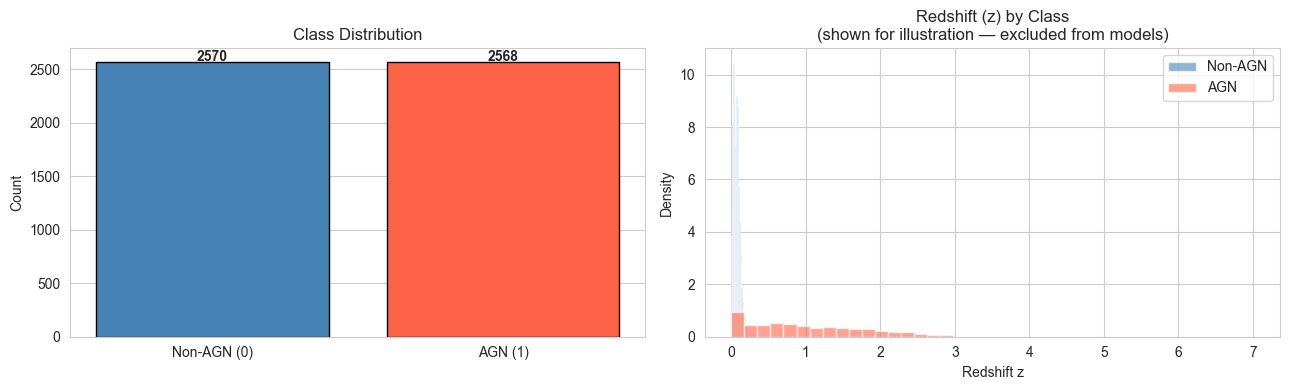

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class balance
counts = df['is_AGN'].value_counts()
axes[0].bar(['Non-AGN (0)', 'AGN (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Redshift — illustrative only, NOT used as a model feature
for label, color, name in [(0, 'steelblue', 'Non-AGN'), (1, 'tomato', 'AGN')]:
    axes[1].hist(df[df['is_AGN'] == label]['z'].dropna(), bins=40,
                 alpha=0.6, color=color, label=name, density=True)
axes[1].set_title('Redshift (z) by Class\n(shown for illustration — excluded from models)')
axes[1].set_xlabel('Redshift z')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2c. BPT Diagnostic Diagram

The **BPT diagram** (Baldwin, Phillips & Terlevich 1981) is the most widely used tool in observational astronomy for classifying galaxies using optical emission lines. It plots:

- **X-axis:** `n2_hA` = log₁₀([NII] / Hα) — nitrogen ionization relative to hydrogen
- **Y-axis:** `o3_hB` = log₁₀([OIII] / Hβ) — oxygen ionization relative to hydrogen

AGN produce harder UV radiation fields than star-forming regions, ionizing gas more powerfully. This causes AGN to appear in the **upper-right** of the diagram. If the classes are well-separated here, these emission line ratios will be among our most important features.

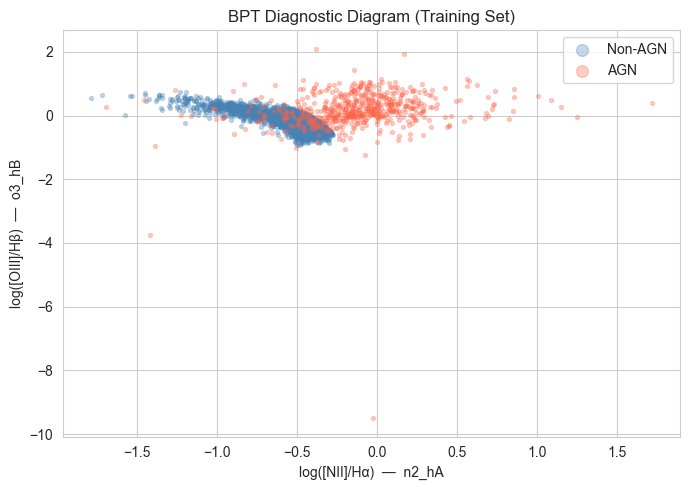

In [38]:
# Replace inf with NaN for plotting only — proper fix happens in preprocessing
df_plot = df.replace([np.inf, -np.inf], np.nan)

fig, ax = plt.subplots(figsize=(7, 5))
for label, color, name in [(0, 'steelblue', 'Non-AGN'), (1, 'tomato', 'AGN')]:
    subset = df_plot[df_plot['is_AGN'] == label]
    ax.scatter(subset['n2_hA'], subset['o3_hB'],
               alpha=0.3, s=8, c=color, label=name)
ax.set_xlabel('log([NII]/Hα)  —  n2_hA')
ax.set_ylabel('log([OIII]/Hβ)  —  o3_hB')
ax.set_title('BPT Diagnostic Diagram (Training Set)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

### 2d. WISE Infrared Color-Color Diagram

The **WISE** telescope observed the sky in four infrared bands (W1–W4). AGN have characteristically warm dust in their accretion disks, making them brighter in the mid-infrared compared to normal galaxies.

The **Stern et al. (2012)** criterion (`w1-w2 > 0.8`) is a well-established threshold for selecting AGN purely from infrared colors.

**Outlier handling:** Some galaxies have extreme `w1-w2` or `w2-w3` values that reflect bad photometry flags rather than real astrophysical measurements. We clip both axes to the **1st–99th percentile range** before plotting to remove these and produce a clean, informative diagram.

Outliers removed for WISE plot: 722 rows (14.1%)


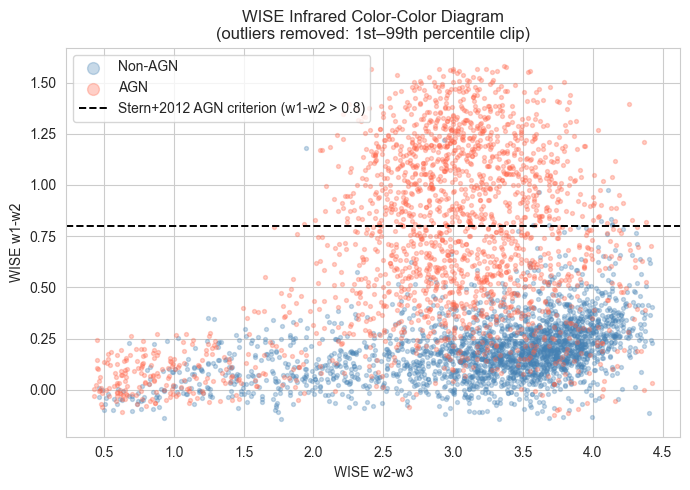

In [39]:
x_col, y_col = 'w2-w3', 'w1-w2'

# Compute percentile clip bounds from the full dataset
x_lo, x_hi = df_plot[x_col].quantile(0.01), df_plot[x_col].quantile(0.99)
y_lo, y_hi = df_plot[y_col].quantile(0.01), df_plot[y_col].quantile(0.99)

# Apply mask — keep only rows within both bounds
mask = (
    df_plot[x_col].between(x_lo, x_hi) &
    df_plot[y_col].between(y_lo, y_hi)
)
df_wise = df_plot[mask]
n_removed = len(df_plot) - mask.sum()
print(f'Outliers removed for WISE plot: {n_removed} rows ({n_removed/len(df_plot):.1%})')

fig, ax = plt.subplots(figsize=(7, 5))
for label, color, name in [(0, 'steelblue', 'Non-AGN'), (1, 'tomato', 'AGN')]:
    subset = df_wise[df_wise['is_AGN'] == label]
    ax.scatter(subset[x_col], subset[y_col],
               alpha=0.3, s=8, c=color, label=name)
ax.axhline(y=0.8, color='black', linestyle='--', linewidth=1.4,
           label='Stern+2012 AGN criterion (w1-w2 > 0.8)')
ax.set_xlabel('WISE w2-w3')
ax.set_ylabel('WISE w1-w2')
ax.set_title('WISE Infrared Color-Color Diagram\n(outliers removed: 1st–99th percentile clip)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering & Preprocessing

This section prepares the data for modeling across four steps.

### Step 1 — Drop Non-Feature Columns

| Column type | Examples | Why excluded |
|---|---|---|
| ID / catalog columns | `ext_ID`, `objID`, `specObjID`, `Unnamed: 0` | Reference numbers with no physical meaning — using them would let the model memorize IDs instead of learning patterns (*data leakage*). |
| Redshift | `z` | Biased in training set — see Section 1 note. |
| Secondary target | `which_AGN` | Another version of the answer — using it as input is cheating. |
| Raw flux columns | `h_alpha_flux`, etc. | Already encoded in the log-ratio features (`o3_hB`, `n2_hA`, etc.), which are physically more meaningful and scale-invariant. |

In [40]:
TARGET = 'is_AGN'

ID_COLS       = ['ext_ID', 'objID', 'specObjID', 'Unnamed: 0']
REDSHIFT_COLS = ['z']  # excluded: biased toward AGN in training set
FLUX_COLS     = ['h_alpha_flux', 'h_beta_flux', 'oiii_5007_flux', 'nii_6584_flux',
                 'sii_6717_flux', 'sii_6731_flux', 'oi_6300_flux', 'oii_3726_flux',
                 'neiii_3869_flux', 'wise_cntr']

ALL_DROP = ID_COLS + REDSHIFT_COLS + ['which_AGN'] + FLUX_COLS + [TARGET]
ALL_DROP = [c for c in ALL_DROP if c in df.columns]

X = df.drop(columns=ALL_DROP, errors='ignore')
y = df[TARGET].astype(int)

print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape:  {y.shape}')
print(f'\nFeatures used ({len(X.columns)}):')
print(X.columns.tolist())

Feature matrix shape: (5138, 31)
Target vector shape:  (5138,)

Features used (31):
['u_mag', 'g_mag', 'r_mag', 'i_mag', 'z_mag', 'w1mpro', 'w2mpro', 'w3mpro', 'w4mpro', 'o3_hB', 'n2_hA', 's2_hA', 'o1_hA', 'o3_o2', 'ne3_o2', 'u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z', 'w1-w2', 'w1-w3', 'w1-w4', 'w2-w3', 'w2-w4', 'w3-w4']


### Step 2 — Train / Test Split

We split the 5,138 labeled galaxies into:
- **80% training set** (~4,110 galaxies) — the model learns patterns from these
- **20% test set** (~1,028 galaxies) — held back entirely, used only at the end to evaluate real-world performance

Think of it like studying with practice problems (train) then sitting an exam on new questions (test). Evaluating on the same data used for training would give an unrealistically inflated score.

- **`stratify=y`** preserves the ~50/50 AGN ratio in both splits
- **`random_state=42`** ensures the same split every run (reproducibility)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples  |  AGN: {y_train.sum()} ({y_train.mean():.1%})')
print(f'Test set:     {X_test.shape[0]} samples  |  AGN: {y_test.sum()} ({y_test.mean():.1%})')

Training set: 4110 samples  |  AGN: 2056 (50.0%)
Test set:     1028 samples  |  AGN: 514 (50.0%)


### Step 3 — Replace inf with NaN

Log-ratio features (e.g. `o3_hB = log10(OIII / Hβ)`) produce `±inf` when the denominator flux is zero. `scikit-learn`'s `SimpleImputer` handles `NaN` fine but **crashes on `inf`** — this was the root cause of the `ValueError` we encountered.

**Fix:** Convert all `inf` / `-inf` to `NaN` before the pipeline. The imputer will then fill them with the column median just like any other missing value.

> This is done after the train/test split so each set is cleaned independently, with no risk of test-set statistics influencing the training data.

In [42]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

affected = np.isinf(X_train.select_dtypes(include=[np.number])).sum()
affected = affected[affected > 0]
if len(affected) > 0:
    print('Columns where inf was replaced with NaN (train set):')
    print(affected)
else:
    print('No inf values found — data is clean.')

No inf values found — data is clean.


### Step 4 — Impute Missing Values & Scale Features

Two transformations are chained in a `Pipeline`:

| Step | Transformer | What it does | Why |
|---|---|---|---|
| 1 | `SimpleImputer(strategy='median')` | Fills `NaN` with the **median** of each column | Galaxies not detected in a band have missing photometry. Median is more robust than mean for skewed distributions. |
| 2 | `StandardScaler()` | Rescales features to **mean=0, std=1** | Both LR and SVM are sensitive to feature scale. Without scaling, `u_mag ≈ 20` would numerically dominate `w1-w2 ≈ 0.3`, regardless of actual predictive importance. |

**Golden rule:** `fit_transform()` is called **only on the training set** — statistics (median, mean, std) are learned from training data only. `transform()` applies those same learned values to the test set. Fitting on test data = data leakage = falsely optimistic scores.

In [43]:
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

X_train_scaled = preprocessor.fit_transform(X_train)  # fit + transform on train
X_test_scaled  = preprocessor.transform(X_test)        # transform only on test

# Sanity check
assert not np.isnan(X_train_scaled).any(), 'ERROR: NaN in training data!'
assert not np.isinf(X_train_scaled).any(), 'ERROR: Inf in training data!'
assert not np.isnan(X_test_scaled).any(),  'ERROR: NaN in test data!'
assert not np.isinf(X_test_scaled).any(),  'ERROR: Inf in test data!'

print('Preprocessing complete — sanity check passed (no NaN or inf remain).')
print(f'Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}')

Preprocessing complete — sanity check passed (no NaN or inf remain).
Train: (4110, 31)  |  Test: (1028, 31)


---
## 4. Model 1 — Logistic Regression

**What it does:** Despite the name, Logistic Regression is a *classification* model. It computes a weighted sum of all features, passes the result through a sigmoid function (which outputs a probability between 0 and 1), and classifies as AGN if the probability exceeds 0.5.

Mathematically: $P(\text{AGN}) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$

Think of it as finding the best flat dividing surface through the feature space.

**Key hyperparameters:**

| Parameter | Value | Meaning |
|---|---|---|
| `C` | 1.0 | Inverse regularization — controls how tightly the model can fit the training data. Lower C = simpler, more general model. |
| `penalty` | `'l2'` | Ridge regularization — slightly shrinks all coefficients, preventing any single feature from dominating. |
| `solver` | `'lbfgs'` | Efficient optimization algorithm for L2 penalty on medium datasets. |
| `max_iter` | 1000 | Maximum optimization iterations — set high to guarantee convergence. |

In [44]:
lr_model = LogisticRegression(
    C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42
)
lr_model.fit(X_train_scaled, y_train)
print('Logistic Regression training complete.')

Logistic Regression training complete.


### Cross-Validation

Before looking at the test set, we run **5-fold stratified cross-validation** on the training data:
1. Split training data into 5 equal chunks
2. Train on 4 chunks, evaluate on the 5th
3. Rotate which chunk is held out — repeat 5 times, average the scores

This is more reliable than a single evaluation and helps detect overfitting. We use **ROC-AUC** as our primary scoring metric — see Section 6 for a full explanation.

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print('Logistic Regression — 5-Fold CV ROC-AUC:')
print(f'  Per fold:  {lr_cv_scores.round(4)}')
print(f'  Mean ± SD: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')

Logistic Regression — 5-Fold CV ROC-AUC:
  Per fold:  [0.9824 0.9833 0.9792 0.9822 0.9764]
  Mean ± SD: 0.9807 ± 0.0025


In [46]:
y_pred_lr  = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression — Test Set Performance ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, y_proba_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Non-AGN', 'AGN']))

=== Logistic Regression — Test Set Performance ===
Accuracy: 0.9621
ROC-AUC:  0.9853

              precision    recall  f1-score   support

     Non-AGN       0.95      0.98      0.96       514
         AGN       0.98      0.95      0.96       514

    accuracy                           0.96      1028
   macro avg       0.96      0.96      0.96      1028
weighted avg       0.96      0.96      0.96      1028



### Feature Importance (Coefficients)

Because all features were standardized to the same scale, the **magnitude of each coefficient** directly reflects that feature's influence on the model — they are comparable across all features.

- **Red (positive):** Feature pushes prediction toward AGN
- **Blue (negative):** Feature pushes prediction toward non-AGN

This interpretability is a key advantage of Logistic Regression — we can directly see which physical measurements the model is relying on.

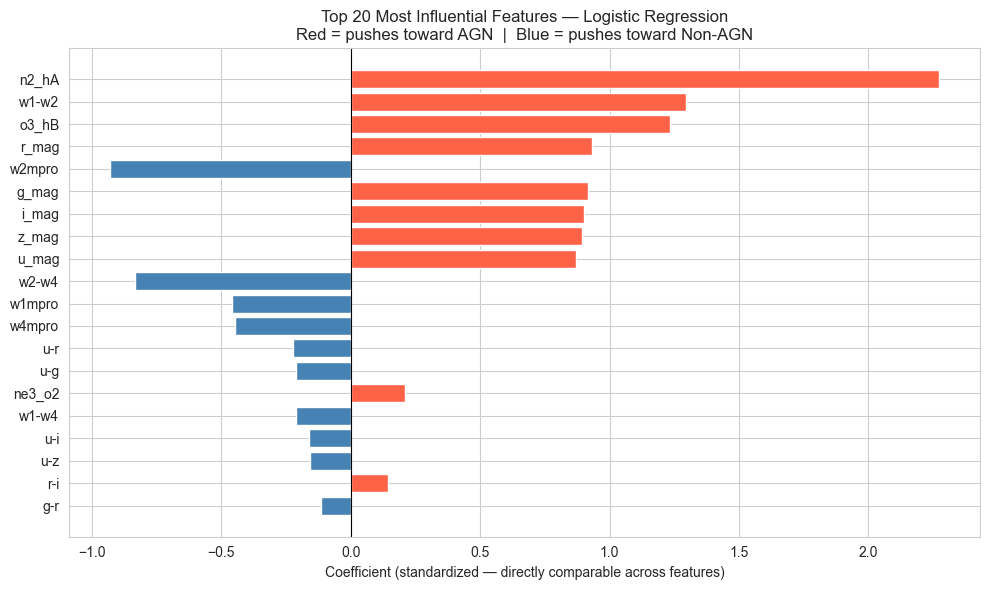

In [47]:
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': lr_model.coef_[0]})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)

top20  = coef_df.head(20)
colors = ['tomato' if c > 0 else 'steelblue' for c in top20['coefficient']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20['feature'], top20['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (standardized — directly comparable across features)')
ax.set_title('Top 20 Most Influential Features — Logistic Regression\n'
             'Red = pushes toward AGN  |  Blue = pushes toward Non-AGN')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. Model 2 — Support Vector Machine (SVM)

**What it does:** An SVM finds the **widest possible gap (margin)** between the two classes. The boundary is defined by the *support vectors* — the training points closest to the dividing line. By maximizing the margin, the SVM is designed to generalize well to unseen data.

We use the **RBF (Radial Basis Function) kernel**, which allows *curved, non-linear* decision boundaries. This is more expressive than Logistic Regression's flat boundary and can capture complex patterns in the data.

**Key hyperparameters:**

| Parameter | Value | Meaning |
|---|---|---|
| `kernel` | `'rbf'` | Enables curved, non-linear decision boundaries by implicitly mapping data into higher dimensions. |
| `C` | 1.0 | Trade-off between maximizing margin (simple) and minimizing training errors (tight fit). Higher C = tighter fit, higher overfitting risk. |
| `gamma` | `'scale'` | Controls the influence radius of each training point. `'scale'` automatically computes a sensible value: 1 / (n_features × variance). |
| `probability` | `True` | Enables `predict_proba()` for ROC-AUC calculation. Adds slight computational overhead via Platt scaling. |

In [48]:
svm_model = SVC(
    C=1.0, kernel='rbf', gamma='scale', probability=True, random_state=42
)
svm_model.fit(X_train_scaled, y_train)
print('SVM (RBF kernel) training complete.')

SVM (RBF kernel) training complete.


In [49]:
svm_cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print('SVM (RBF) — 5-Fold CV ROC-AUC:')
print(f'  Per fold:  {svm_cv_scores.round(4)}')
print(f'  Mean ± SD: {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}')

SVM (RBF) — 5-Fold CV ROC-AUC:
  Per fold:  [0.9981 0.9985 0.9963 0.9965 0.9926]
  Mean ± SD: 0.9964 ± 0.0021


In [50]:
y_pred_svm  = svm_model.predict(X_test_scaled)
y_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print('=== SVM (RBF) — Test Set Performance ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, y_proba_svm):.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=['Non-AGN', 'AGN']))

=== SVM (RBF) — Test Set Performance ===
Accuracy: 0.9776
ROC-AUC:  0.9969

              precision    recall  f1-score   support

     Non-AGN       0.97      0.99      0.98       514
         AGN       0.99      0.97      0.98       514

    accuracy                           0.98      1028
   macro avg       0.98      0.98      0.98      1028
weighted avg       0.98      0.98      0.98      1028



---
## 6. Model Comparison & Evaluation

We evaluate both models with four complementary metrics:

| Metric | Definition | Notes |
|---|---|---|
| **Accuracy** | % of all galaxies correctly labeled | Not our primary metric — can be misleading even with balanced classes. |
| **ROC-AUC** | Area under the ROC curve — how well the model ranks AGN above non-AGN across all probability thresholds | **Our primary metric.** 1.0 = perfect, 0.5 = random. |
| **Precision** | Of galaxies predicted as AGN, what fraction actually are? | Measures false alarm rate. |
| **Recall** | Of all true AGN, what fraction did we catch? | Measures missed AGN — critical for discovery science. |

**Confusion matrix cells:**
- TN (top-left): non-AGN correctly identified
- FP (top-right): non-AGN wrongly flagged as AGN
- **FN (bottom-left): real AGN we missed ← highest cost for our discovery goal**
- TP (bottom-right): AGN correctly identified

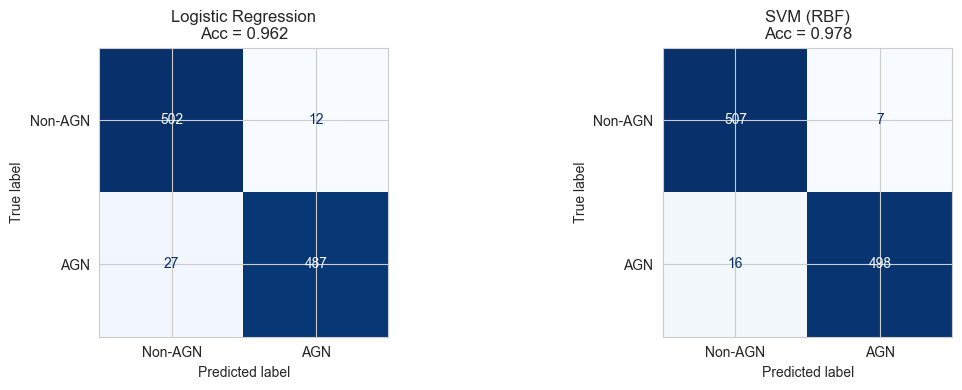

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, title in zip(
    axes, [y_pred_lr, y_pred_svm], ['Logistic Regression', 'SVM (RBF)']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Non-AGN', 'AGN']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'{title}\nAcc = {accuracy_score(y_test, y_pred):.3f}')
plt.tight_layout()
plt.show()

### ROC Curves

The **ROC curve** plots True Positive Rate (recall — fraction of AGN caught) against False Positive Rate (fraction of non-AGN incorrectly flagged), sweeping across all possible probability thresholds.

- A curve hugging the **top-left corner** = better model (high recall, low false alarms)
- The **dashed diagonal** = random guessing (AUC = 0.5)
- **AUC** summarizes the entire curve as a single number

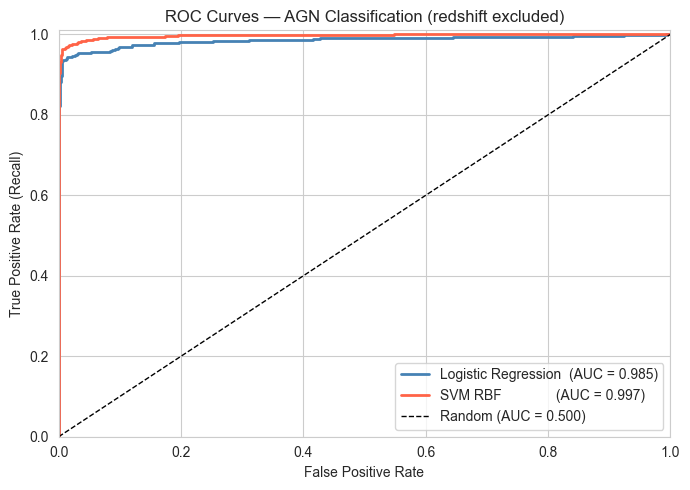

In [52]:
fig, ax = plt.subplots(figsize=(7, 5))
for y_proba, label, color in [
    (y_proba_lr,  f'Logistic Regression  (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})',  'steelblue'),
    (y_proba_svm, f'SVM RBF              (AUC = {roc_auc_score(y_test, y_proba_svm):.3f})', 'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=label, linewidth=2, color=color)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — AGN Classification (redshift excluded)')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.show()

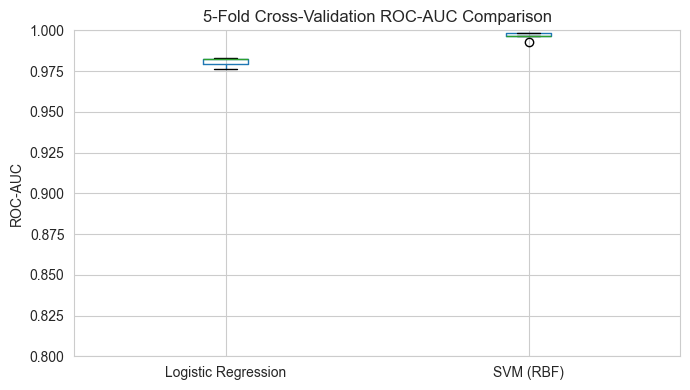

In [53]:
# Cross-validation boxplot — tight box = consistently reliable across folds
fig, ax = plt.subplots(figsize=(7, 4))
pd.DataFrame({'Logistic Regression': lr_cv_scores, 'SVM (RBF)': svm_cv_scores}).boxplot(ax=ax)
ax.set_ylabel('ROC-AUC')
ax.set_title('5-Fold Cross-Validation ROC-AUC Comparison')
ax.set_ylim([0.80, 1.0])
plt.tight_layout()
plt.show()

In [54]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM (RBF)'],
    'CV AUC (mean)':  [lr_cv_scores.mean(),                svm_cv_scores.mean()],
    'CV AUC (std)':   [lr_cv_scores.std(),                 svm_cv_scores.std()],
    'Test Accuracy':  [accuracy_score(y_test, y_pred_lr),  accuracy_score(y_test, y_pred_svm)],
    'Test ROC-AUC':   [roc_auc_score(y_test, y_proba_lr),  roc_auc_score(y_test, y_proba_svm)],
    'Test Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_svm)],
    'Test Recall':    [recall_score(y_test, y_pred_lr),    recall_score(y_test, y_pred_svm)],
    'Test F1':        [f1_score(y_test, y_pred_lr),        f1_score(y_test, y_pred_svm)],
}).set_index('Model').round(4)

print('=== Final Model Comparison (redshift excluded) ===')
summary

=== Final Model Comparison (redshift excluded) ===


,CV AUC (mean),CV AUC (std),Test Accuracy,Test ROC-AUC,Test Precision,Test Recall,Test F1
Model,,,,,,,
Logistic Regression,0.9807,0.0025,0.9621,0.9853,0.9760,0.9475,0.9615
SVM (RBF),0.9964,0.0021,0.9776,0.9969,0.9861,0.9689,0.9774


---
## 7. Apply Best Model to `test_dataset.csv` (Unlabeled Inference)

With the best model selected from Section 6, we apply it to all **42,814 unlabeled SDSS galaxies** in `test_dataset.csv`.

Each galaxy receives:
- `pred_is_AGN` — hard label: `0` (non-AGN) or `1` (AGN)
- `pred_AGN_proba` — probability score between 0 and 1

Galaxies with **probability > 0.80** are flagged as high-confidence AGN candidates, suitable for cross-matching against the SDSS DR12 quasar catalog to evaluate the model's discovery potential.

**Important:** The same preprocessing pipeline (fit on training data) and the same inf → NaN fix are applied here. We never refit the scaler or imputer on the inference data.

In [56]:
df_infer = pd.read_csv('test_dataset.csv')
print(f'Inference dataset shape: {df_infer.shape}')

X_infer = df_infer[X.columns].copy()                         # same features, no redshift
X_infer = X_infer.replace([np.inf, -np.inf], np.nan)         # same inf fix
X_infer_scaled = preprocessor.transform(X_infer)             # same scaler, no refit

print(f'Inference feature matrix shape: {X_infer_scaled.shape}')

Inference dataset shape: (42814, 45)
Inference feature matrix shape: (42814, 31)


In [57]:
best_model = svm_model  # change to lr_model if LR performed better in Section 6

infer_preds  = best_model.predict(X_infer_scaled)
infer_probas = best_model.predict_proba(X_infer_scaled)[:, 1]

df_infer['pred_is_AGN']    = infer_preds
df_infer['pred_AGN_proba'] = infer_probas.round(4)

n_agn = infer_preds.sum()
print(f'Total classified as AGN: {n_agn} / {len(infer_preds)} ({n_agn/len(infer_preds):.1%})')
df_infer[['objID', 'pred_is_AGN', 'pred_AGN_proba']].head(10)

Total classified as AGN: 20203 / 42814 (47.2%)


,objID,pred_is_AGN,pred_AGN_proba
0,1237651250947293276,0,0.1456
1,1237651272961622132,0,0.4348
2,1237651272425275578,1,0.9887
3,1237651192433344532,0,0.2089
4,1237651533873873037,1,0.9791
5,1237654605866074191,1,0.9696
6,1237661063871594762,1,1.0000
7,1237662619189903666,1,1.0000
8,1237662619724873992,0,0.1688
9,1237671938743011428,0,0.1122


In [58]:
high_conf = df_infer[df_infer['pred_AGN_proba'] > 0.80]
print(f'High-confidence AGN candidates (prob > 0.80): {len(high_conf)}')

df_infer[['objID', 'pred_is_AGN', 'pred_AGN_proba']].to_csv('test_predictions.csv', index=False)
print('Saved predictions to test_predictions.csv')

High-confidence AGN candidates (prob > 0.80): 18002
Saved predictions to test_predictions.csv


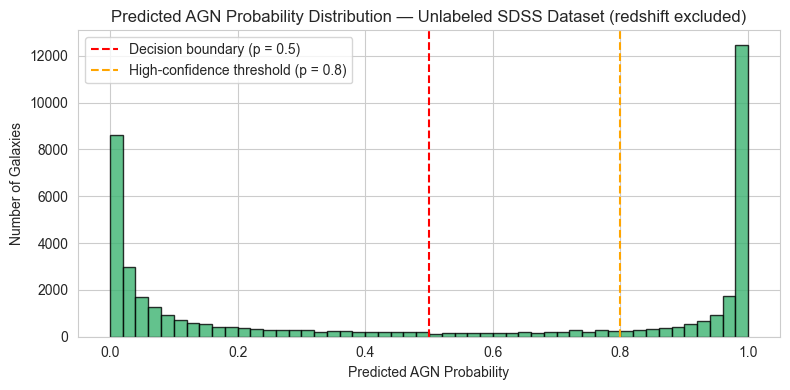

In [59]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(infer_probas, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.8)
ax.axvline(x=0.5, color='red',    linestyle='--', label='Decision boundary (p = 0.5)')
ax.axvline(x=0.8, color='orange', linestyle='--', label='High-confidence threshold (p = 0.8)')
ax.set_xlabel('Predicted AGN Probability')
ax.set_ylabel('Number of Galaxies')
ax.set_title('Predicted AGN Probability Distribution — Unlabeled SDSS Dataset (redshift excluded)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

| Step | What we did |
|---|---|
| **Data** | Loaded `train_dataset.csv` (5,138 labeled galaxies, ~50/50 AGN) |
| **Redshift excluded** | `z` dropped — biased in training set due to sample construction, not physical |
| **WISE plot** | Outliers removed via 1st–99th percentile clip |
| **inf fix** | `±inf` from log-ratio features converted to `NaN` before imputing |
| **Preprocessing** | Dropped ID/meta columns · imputed NaN with median · standardized features |
| **Split** | 80/20 stratified train/test split (`random_state=42`) |
| **Model 1** | Logistic Regression (L2, C=1.0) |
| **Model 2** | SVM with RBF kernel (C=1.0, gamma='scale') |
| **Evaluation** | 5-fold CV ROC-AUC · accuracy · precision · recall · F1 · confusion matrices · ROC curves |
| **Inference** | Applied best model to 42,814 unlabeled SDSS galaxies · saved to `test_predictions.csv` |

